<a href="https://colab.research.google.com/github/TanviDhuri18/CSL701-CS13_Machine-Learning-Lab/blob/main/CS13_ML_Experiment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name:Tanvi Dasharath Dhuri  Roll No :CS13  Batch:CS01

Aim

To implement Support Vector Machine (SVM) for classification of the Iris dataset and visualize its decision boundary and compare it with a normal linear classification boundary.

## Objectives

1. To understand the concept of Support Vector Machine.
2. To implement SVM using Python.
3. To visualize the SVM decision boundary.
4. To identify the support vectors.
5. To compare the SVM boundary with a normal linear classification boundary.
6. To evaluate the performance of the classifiers.

# Relevant Theory

### Support Vector Machine

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification.

SVM finds a decision boundary that separates different classes while trying to maximize the distance, called the **margin**, between the classes.

The points closest to the decision boundary are called **support vectors**.

For a linear SVM, the decision boundary can be represented as:

$$
w^T x + b = 0
$$

where:

- $w$ = weight vector
- $x$ = input features
- $b$ = bias


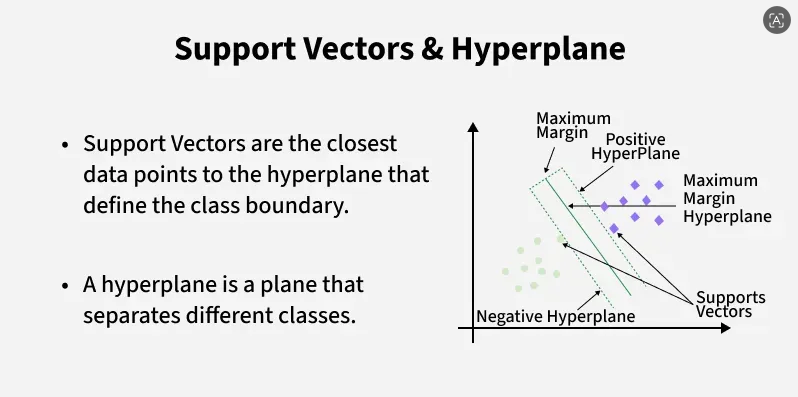
### Kernel

SVM can use different kernels to create decision boundaries.

Common kernels are:

- Linear
- Polynomial
- RBF
- Sigmoid

In this experiment, we mainly use the **Linear SVM** and **RBF SVM**.

---

# Dataset Information

Get the IRIS dataset from Kaggle using below link

https://www.kaggle.com/datasets/uciml/iris

The Iris dataset contains measurements of Iris flowers belonging to three classes:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

The four features are:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

For visualization, we will use:

**Petal Length and Petal Width.**

# Task 1: Import Libraries and Load Dataset

Load the Iris dataset.

---

In [4]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Iris dataset directly
from sklearn.datasets import load_iris

iris = load_iris()

# Create DataFrame
df = pd.DataFrame(
    iris.data,
    columns=[
        "SepalLengthCm",
        "SepalWidthCm",
        "PetalLengthCm",
        "PetalWidthCm"
    ]
)

# Add target/species column
df["Species"] = iris.target_names[iris.target]

# Display first 5 rows
print("First 5 rows of the dataset:")
display(df.head())

# Display dataset information
print("\nDataset Information:")
df.info()

First 5 rows of the dataset:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


# Task 2: Explore the Dataset

In [5]:
# Task 2: Explore the Dataset

# Display the first 5 rows
print("First 5 rows:")
display(df.head())

# Display the last 5 rows
print("\nLast 5 rows:")
display(df.tail())

# Display number of rows and columns
print("\nShape of the dataset:")
print(df.shape)

# Display column names
print("\nColumn names:")
print(df.columns)

# Display dataset information
print("\nDataset information:")
df.info()

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Display statistical summary
print("\nStatistical Summary:")
display(df.describe())

# Display number of samples in each species
print("\nSpecies distribution:")
print(df["Species"].value_counts())

First 5 rows:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Last 5 rows:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica



Shape of the dataset:
(150, 5)

Column names:
Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Missing values:
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Statistical Summary:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



Species distribution:
Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


# Task 3: Select Features and Target

Remove the `Id` column.

Select Remaining Features

In [6]:
# Task 3: Select Features and Target

# Remove the Id column if it exists
if "Id" in df.columns:
    df = df.drop("Id", axis=1)

# Select features
X = df[[
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm"
]]

# Select target
y = df["Species"]

# Display features and target
print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

# Display shapes
print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Features:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



Target:


,Species
0,setosa
1,setosa
2,setosa
3,setosa
4,setosa



Feature shape: (150, 4)
Target shape: (150,)


In [7]:
# Select only Petal Length and Petal Width for visualization
X_visual = df[["PetalLengthCm", "PetalWidthCm"]]

print("Selected features for SVM visualization:")
display(X_visual.head())

print("\nShape:", X_visual.shape)

Selected features for SVM visualization:


,PetalLengthCm,PetalWidthCm
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2



Shape: (150, 2)


# Task 4: Split and Scale the Data

Divide the dataset into training and testing sets.

In [8]:
# Task 4: Split and Scale the Data

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_visual,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create StandardScaler
scaler = StandardScaler()

# Fit scaler on training data and transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data using the same scaler
X_test_scaled = scaler.transform(X_test)

# Display shapes
print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training data shape: (120, 2)
Testing data shape: (30, 2)
Training target shape: (120,)
Testing target shape: (30,)


# Task 5: Implement Linear SVM

Create an SVM model using a **linear kernel**.

Make predictions.

In [9]:
# Task 5: Implement Linear SVM

from sklearn.svm import SVC

# Create Linear SVM model
linear_svm = SVC(
    kernel="linear",
    random_state=42
)

# Train the model
linear_svm.fit(X_train_scaled, y_train)

# Make predictions
y_pred_linear = linear_svm.predict(X_test_scaled)

# Display predictions
print("Predicted values:")
print(y_pred_linear)

print("\nActual values:")
print(y_test.values)

Predicted values:
['setosa' 'virginica' 'versicolor' 'versicolor' 'setosa' 'versicolor'
 'setosa' 'setosa' 'virginica' 'versicolor' 'virginica' 'virginica'
 'virginica' 'versicolor' 'setosa' 'setosa' 'setosa' 'versicolor'
 'versicolor' 'virginica' 'setosa' 'virginica' 'versicolor' 'versicolor'
 'virginica' 'virginica' 'versicolor' 'setosa' 'virginica' 'setosa']

Actual values:
['setosa' 'virginica' 'versicolor' 'versicolor' 'setosa' 'versicolor'
 'setosa' 'setosa' 'virginica' 'versicolor' 'virginica' 'virginica'
 'virginica' 'versicolor' 'setosa' 'setosa' 'setosa' 'versicolor'
 'versicolor' 'virginica' 'setosa' 'virginica' 'versicolor' 'virginica'
 'virginica' 'versicolor' 'versicolor' 'setosa' 'virginica' 'setosa']


# Task 6: Evaluate SVM

### Calculate Accuracy

Calculate the accuracy of the SVM model.

### Confusion Matrix

Generate the confusion matrix to evaluate the classification results.

### Classification Report

Generate the classification report containing:

- Precision
- Recall
- F1-Score
- Support

---


Linear SVM Accuracy: 0.9333333333333333

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


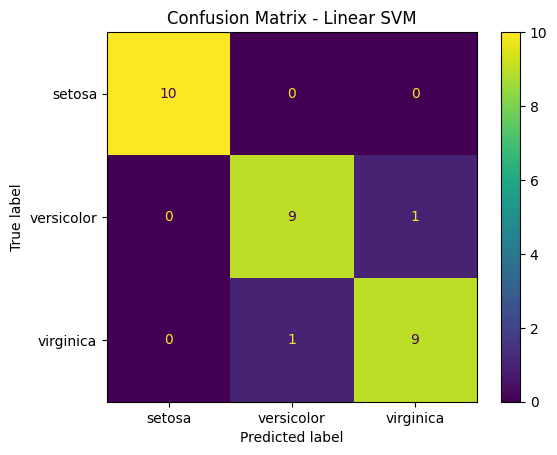


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [10]:
# Task 6: Evaluate Linear SVM

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Calculate accuracy
accuracy_svm = accuracy_score(y_test, y_pred_linear)

print("Linear SVM Accuracy:", accuracy_svm)

# Generate confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_linear)

print("\nConfusion Matrix:")
print(cm_svm)

# Display confusion matrix graph
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=linear_svm.classes_
)

disp.plot()
plt.title("Confusion Matrix - Linear SVM")
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_linear))

# Task 7: Visualize SVM Decision Boundary

For visualization, we use only two features:

- Petal Length
- Petal Width

### Create the 2-D Dataset

Select **Petal Length** and **Petal Width** as the input features.

### Split the Data

Divide the 2-D dataset into training and testing sets.

### Scale the Data

Standardize the selected features before training the SVM model.

### Train SVM

Train an SVM classifier using a **linear kernel**.

### Plot Decision Boundary

Visualize the SVM decision boundary along with the data points.

---

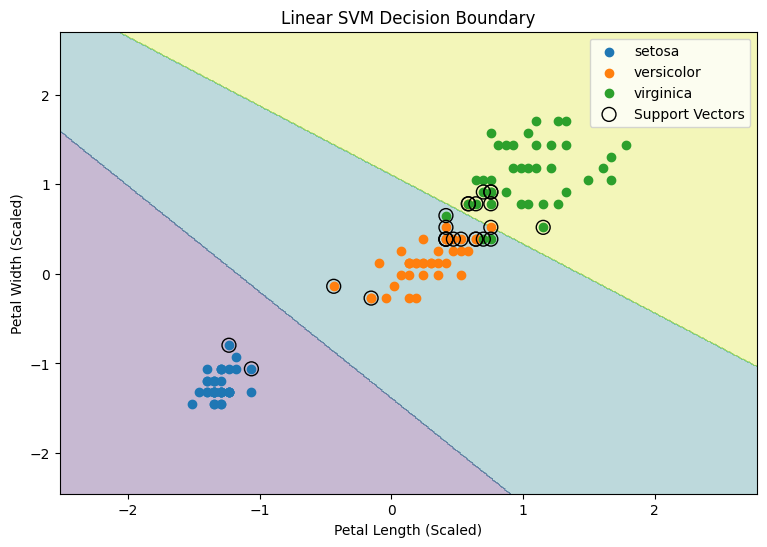

Number of support vectors: 24


In [11]:
# Task 7: Visualize SVM Decision Boundary

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Create 2-D dataset
X_2D = df[["PetalLengthCm", "PetalWidthCm"]]
y_2D = df["Species"]

# Split the data
X_train_2D, X_test_2D, y_train_2D, y_test_2D = train_test_split(
    X_2D,
    y_2D,
    test_size=0.2,
    random_state=42,
    stratify=y_2D
)

# Scale the data
scaler_2D = StandardScaler()

X_train_2D_scaled = scaler_2D.fit_transform(X_train_2D)
X_test_2D_scaled = scaler_2D.transform(X_test_2D)

# Train Linear SVM
svm_2D = SVC(
    kernel="linear",
    random_state=42
)

svm_2D.fit(X_train_2D_scaled, y_train_2D)

# Create mesh grid
x_min = X_train_2D_scaled[:, 0].min() - 1
x_max = X_train_2D_scaled[:, 0].max() + 1

y_min = X_train_2D_scaled[:, 1].min() - 1
y_max = X_train_2D_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# Predict for every point in the grid
grid_predictions = svm_2D.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

# Convert predictions to numerical values
class_names = svm_2D.classes_
class_to_number = {
    class_name: number
    for number, class_name in enumerate(class_names)
}

Z = np.array([
    class_to_number[prediction]
    for prediction in grid_predictions
])

Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(9, 6))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.3
)

# Plot training points
for i, class_name in enumerate(class_names):
    mask = y_train_2D.values == class_name

    plt.scatter(
        X_train_2D_scaled[mask, 0],
        X_train_2D_scaled[mask, 1],
        label=class_name
    )

# Highlight support vectors
plt.scatter(
    svm_2D.support_vectors_[:, 0],
    svm_2D.support_vectors_[:, 1],
    s=100,
    facecolors="none",
    edgecolors="black",
    label="Support Vectors"
)

plt.xlabel("Petal Length (Scaled)")
plt.ylabel("Petal Width (Scaled)")
plt.title("Linear SVM Decision Boundary")
plt.legend()
plt.show()

print("Number of support vectors:", len(svm_2D.support_))

# Task 8: Normal Linear Classification Boundary

For comparison, we use **Logistic Regression** as a normal linear classifier.

Train a Logistic Regression model using the same two features and visualize its decision boundary.

---

In [12]:
# Task 8: Logistic Regression

from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
logistic_model.fit(X_train_2D_scaled, y_train_2D)

# Make predictions
y_pred_logistic = logistic_model.predict(X_test_2D_scaled)

# Calculate accuracy
accuracy_logistic = accuracy_score(
    y_test_2D,
    y_pred_logistic
)

print("Logistic Regression Accuracy:", accuracy_logistic)

Logistic Regression Accuracy: 0.9333333333333333


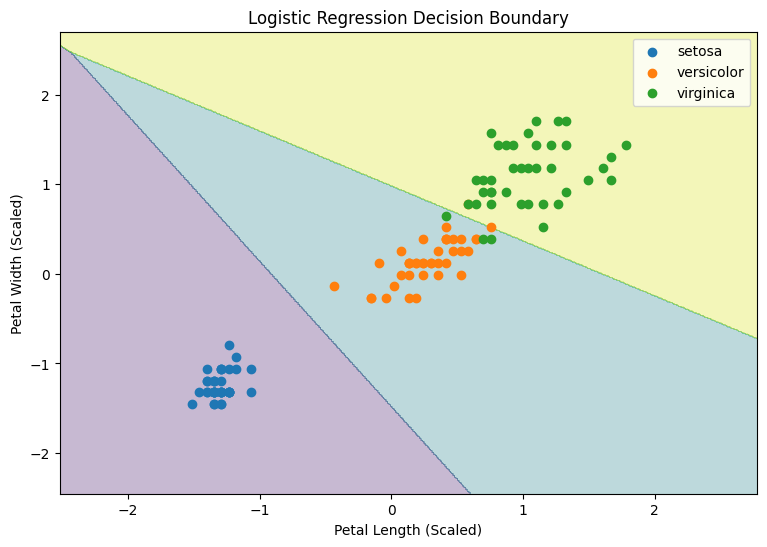

In [13]:
# Create predictions for mesh grid
logistic_grid_predictions = logistic_model.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z_logistic = np.array([
    class_to_number[prediction]
    for prediction in logistic_grid_predictions
])

Z_logistic = Z_logistic.reshape(xx.shape)

# Plot Logistic Regression boundary
plt.figure(figsize=(9, 6))

plt.contourf(
    xx,
    yy,
    Z_logistic,
    alpha=0.3
)

# Plot training data
for class_name in class_names:
    mask = y_train_2D.values == class_name

    plt.scatter(
        X_train_2D_scaled[mask, 0],
        X_train_2D_scaled[mask, 1],
        label=class_name
    )

plt.xlabel("Petal Length (Scaled)")
plt.ylabel("Petal Width (Scaled)")
plt.title("Logistic Regression Decision Boundary")
plt.legend()
plt.show()

# Task 9: Compare SVM and Normal Boundary

Plot both the **SVM** and **Logistic Regression** decision boundaries on the same graph.

Compare how the two classifiers separate the different classes.

---

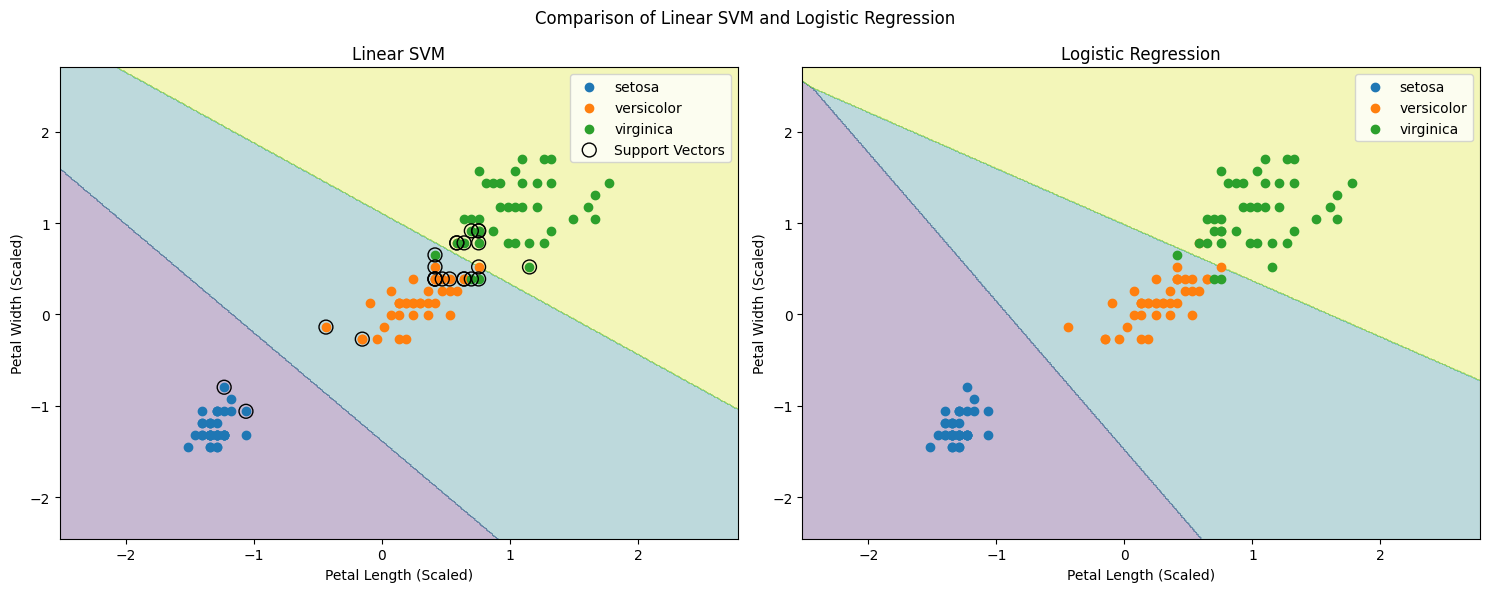

In [14]:
# Task 9: Compare SVM and Logistic Regression

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# -----------------------------
# Linear SVM
# -----------------------------
axes[0].contourf(
    xx,
    yy,
    Z,
    alpha=0.3
)

for class_name in class_names:
    mask = y_train_2D.values == class_name

    axes[0].scatter(
        X_train_2D_scaled[mask, 0],
        X_train_2D_scaled[mask, 1],
        label=class_name
    )

# Support vectors
axes[0].scatter(
    svm_2D.support_vectors_[:, 0],
    svm_2D.support_vectors_[:, 1],
    s=100,
    facecolors="none",
    edgecolors="black",
    label="Support Vectors"
)

axes[0].set_title("Linear SVM")
axes[0].set_xlabel("Petal Length (Scaled)")
axes[0].set_ylabel("Petal Width (Scaled)")
axes[0].legend()

# -----------------------------
# Logistic Regression
# -----------------------------
axes[1].contourf(
    xx,
    yy,
    Z_logistic,
    alpha=0.3
)

for class_name in class_names:
    mask = y_train_2D.values == class_name

    axes[1].scatter(
        X_train_2D_scaled[mask, 0],
        X_train_2D_scaled[mask, 1],
        label=class_name
    )

axes[1].set_title("Logistic Regression")
axes[1].set_xlabel("Petal Length (Scaled)")
axes[1].set_ylabel("Petal Width (Scaled)")
axes[1].legend()

plt.suptitle("Comparison of Linear SVM and Logistic Regression")
plt.tight_layout()
plt.show()

# Task 10: Compare Performance

Compare the performance of the **Linear SVM** and **Logistic Regression** using:

- Accuracy
- Confusion Matrix
- Classification Report

---

===== ACCURACY COMPARISON =====
Linear SVM          : 0.9333333333333333
Logistic Regression : 0.9333333333333333


<Figure size 700x500 with 0 Axes>

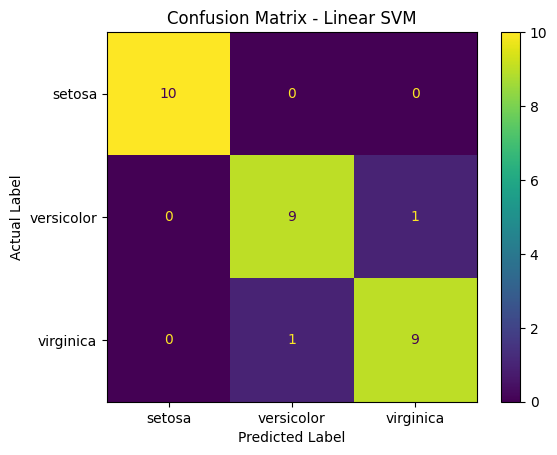

<Figure size 700x500 with 0 Axes>

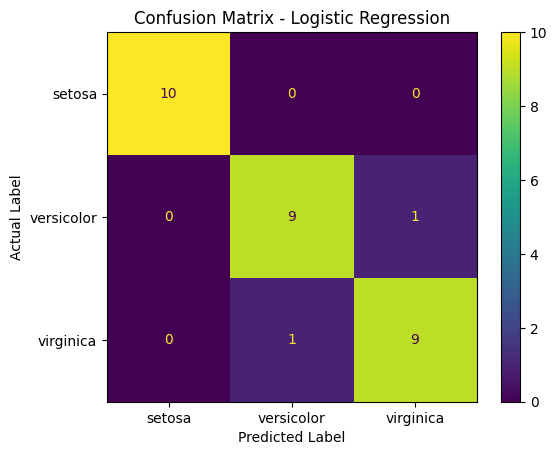


===== LINEAR SVM CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


===== LOGISTIC REGRESSION CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [16]:
# Task 10: Compare Performance

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Make predictions
y_pred_svm = svm_2D.predict(X_test_2D_scaled)
y_pred_logistic = logistic_model.predict(X_test_2D_scaled)

# -----------------------------
# Accuracy
# -----------------------------
accuracy_svm = accuracy_score(y_test_2D, y_pred_svm)
accuracy_logistic = accuracy_score(y_test_2D, y_pred_logistic)

print("===== ACCURACY COMPARISON =====")
print("Linear SVM          :", accuracy_svm)
print("Logistic Regression :", accuracy_logistic)


# -----------------------------
# SVM Confusion Matrix
# -----------------------------
cm_svm = confusion_matrix(y_test_2D, y_pred_svm)

plt.figure(figsize=(7, 5))

disp_svm = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=svm_2D.classes_
)

disp_svm.plot(values_format="d")

plt.title("Confusion Matrix - Linear SVM")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()


# -----------------------------
# Logistic Regression Confusion Matrix
# -----------------------------
cm_logistic = confusion_matrix(
    y_test_2D,
    y_pred_logistic
)

plt.figure(figsize=(7, 5))

disp_logistic = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=logistic_model.classes_
)

disp_logistic.plot(values_format="d")

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()


# -----------------------------
# Classification Report - SVM
# -----------------------------
print("\n===== LINEAR SVM CLASSIFICATION REPORT =====")
print(classification_report(
    y_test_2D,
    y_pred_svm
))


# -----------------------------
# Classification Report - Logistic Regression
# -----------------------------
print("\n===== LOGISTIC REGRESSION CLASSIFICATION REPORT =====")
print(classification_report(
    y_test_2D,
    y_pred_logistic
))

# Conclusion

The experiment successfully demonstrated the implementation of **Support Vector Machine (SVM)** using the Iris dataset. The dataset was preprocessed and standardized before training the model.

A **Linear SVM** was implemented and its decision boundary was visualized along with the support vectors. A normal linear classification boundary using **Logistic Regression** was also visualized for comparison.